# 📗 02. 데이터 EDA — H&M 커머스 탐색적 분석

> 엔코아 AI캠퍼스 · 데이터 분석 & AI 머신러닝 캠프

이 노트북은 **01_데이터이해_전처리**가 만든 정제본으로 **탐색적 데이터 분석(EDA)** 을 합니다. day07(EDA·시각화) 전체와 day08(기술통계)을 이 파트에서 다룹니다 — **추론통계(가설검정·회귀)는 03_데이터_통계**에서 이어집니다.

**이 노트북 읽는 법**
- 각 절 시작에 **"이 절에서 할 일"** 한 줄이 있습니다.
- 이 노트북에는 **완성된 코드가 없습니다.** 각 절이 **무엇을 만들어야 하는지**와 **어떤 도구(함수·핵심 인자)를 쓰는지**를 알려 주니, **코드는 그것을 보고 스스로 쓰세요.**
- 막히면 **"막히면 볼 곳"** 이 가리키는 **day07·day08 교안**에서 필요한 함수를 찾아 쓰세요.
- 각 절 끝에 **"여기까지 되면 통과"** 로 스스로 확인하세요(자가채점 없음).
- **2절(필수 미션)은 반드시**, **3절(선택 카탈로그)은 원하는 것만** — 이 둘은 성격이 다르니 헷갈리지 마세요.

**목차**
1. 정제본 불러오기
2. 필수 EDA 미션 (반드시)
3. 선택 EDA 미션 카탈로그 (골라서)
4. 관찰 정리 (서술)

## 1. 정제본 불러오기
**이 절에서 할 일**: 01 이 저장한 정제본(`output/hm_clean.csv`)을 **직접 불러와**, 이후 모든 절에서 이어 쓸 `df` 와 표본 `df_s`, 파생변수 세 개를 준비합니다.

> ⚠️ **01 을 먼저 끝내야 합니다.** 이 노트북은 01 의 마지막 셀이 저장한 정제본에서 시작합니다. `output/hm_clean.csv` 가 없으면 01 로 돌아가 저장 셀까지 실행하고 오세요. 원본 3개 테이블을 여기서 다시 읽지는 않습니다.

**이 노트북이 쓰는 컬럼** — 01 의 정제본에 아래가 남아 있어야 뒤 절의 지침을 그대로 따를 수 있습니다: `t_dat`·`customer_id`·`article_id`·`price`·`age`·`sales_channel_id`·`club_member_status`·`fashion_news_frequency`·`product_group_name`·`prod_name`·`index_group_name`. 빠진 것이 있으면 01 에서 그 컬럼을 남긴 채 다시 저장하세요.

> 🔧 01 에서 여러분이 고른 처리 규칙(연령 범위·0원 거래·채널 코드·멤버십 결측)이 그대로 반영되므로, 아래 지침의 "이렇게 나오면 맞다"와 **행수·수치가 조금 달라도 정상**입니다.

**1-1. 준비 — 라이브러리와 한글 폰트**

- **무엇을 만드나**: 이 노트북에서 쓸 라이브러리를 한 셀에 모아 불러오고, 그래프의 한글이 깨지지 않게 폰트를 설정합니다.
- **왜**: matplotlib 의 기본 폰트에는 한글 글자가 없어서, 폰트를 지정하지 않으면 그래프의 모든 한글이 네모(□)로 나옵니다.
- **이렇게 나오면 맞다**: 에러 없이 셀이 끝나고, 뒤에서 그린 그래프의 한글 제목이 네모(□) 없이 보입니다.
- **함정**: `sns.set_theme()` 은 `font.family` 를 자기 기본값으로 **되돌립니다** — 폰트를 먼저 지정하고 그 뒤에 `set_theme()` 을 부르면 한글이 다시 깨집니다. 순서를 바꾸거나 `set_theme(font=…)` 로 함께 넘기세요.

In [1]:
# ── 쓸 도구 ─────────────────────────────────────────
#   pandas(pd)·numpy(np)·matplotlib.pyplot(plt)·seaborn(sns) — 별칭은 이 관례 그대로
#     쓰세요(뒤 절 지침이 이 이름으로 설명합니다).
#   from scipy import stats — 절사평균·왜도·첨도에서 씁니다.
#   한글 폰트: platform.system() 으로 OS 를 확인해 Windows 는 'Malgun Gothic',
#     macOS('Darwin')는 'AppleGothic', 그 외(Colab 등)는 'NanumGothic' 을
#     plt.rcParams['font.family'] 에 넣습니다.
#   음수 눈금이 네모로 깨지지 않게 plt.rcParams['axes.unicode_minus'] = False.
#   seaborn 테마를 쓰려면 sns.set_theme(style=…, font=…, rc={'axes.unicode_minus': False})
#     처럼 폰트를 함께 넘깁니다.
#   경고 문구가 시끄러우면 warnings.filterwarnings('ignore').

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import platform
import warnings

# 한글 폰트
if platform.system() == 'Windows':
    KOREAN_FONT = 'Malgun Gothic'
    FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':          # macOS
    KOREAN_FONT = 'AppleGothic'
    FONT_PATH = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:                                        # Linux (Colab 등)
    KOREAN_FONT = 'NanumGothic'
    FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', font='Malgun Gothic', rc={'axes.unicode_minus': False})

warnings.filterwarnings('ignore')

**1-2. 정제본 불러와 `df` 만들기**

- **무엇을 만드나**: 정제본 CSV(`output/hm_clean.csv`)를 읽어 **`df`** 라는 이름으로 두고, 날짜 컬럼 `t_dat` 을 날짜형으로 되돌린 뒤 **데이터를 먼저 훑습니다** — 모양·앞부분·자료형·요약 순서로.
- **왜**: 이 노트북의 모든 절이 **`df`** 라는 이름을 쓴다고 가정합니다. 이름을 다르게 두면 뒤 절의 지침을 그대로 따를 수 없습니다.
- **이렇게 나오면 맞다**: `df.shape` 가 (10만 행 안팎, 30여 컬럼)처럼 찍히고 head·info·describe 표가 보이며, `df['t_dat'].dtype` 이 `datetime64[ns]` 입니다.
- **함정**: CSV 로 저장했다가 다시 읽으면 **날짜형이 문자열로 풀립니다.** 변환을 빠뜨리면 뒤에서 `.dt.month` 를 쓸 때 `Can only use .dt accessor with datetimelike values` 에러가 납니다.

In [2]:
# ── 쓸 도구 ─────────────────────────────────────────
#   읽기: pd.read_csv(<경로>) — 경로는 위의 정제본 경로 그대로.
#   날짜형 변환: pd.to_datetime(<컬럼>) 의 결과를 같은 컬럼에 다시 넣습니다.
#   훑기 4종: 모양 df.shape -> 앞부분 display(df.head(3)) -> 열·자료형·결측 df.info() -> 수치
#     요약 df.describe() (DataFrame 은 print 보다 display 가 표로 예쁘게 나옵니다).
#   범주형 열은 df.describe() 에 안 나옵니다 — df.describe(exclude='number') 로 개수·고유값
#     수·최빈값을 봅니다.

df = pd.read_csv('output/hm_clean.csv')
df['t_dat'] = pd.to_datetime(df['t_dat'])
print(df.shape)
display(df.describe())
print(df['t_dat'].dtype)
display(df.describe(exclude='number'))

(114544, 38)


,t_dat,article_id,price,sales_channel_id,FN,Active,age,product_code,product_type_no,graphical_appearance_no,colour_group_code,perceived_colour_value_id,perceived_colour_master_id,department_no,index_group_no,section_no,garment_group_no,month,age_group
count,114544,1.145440e+05,114544.000000,114544.000000,114544.000000,114544.000000,114544.000000,114544.000000,114544.000000,1.145440e+05,114544.000000,114544.000000,114544.000000,114544.000000,114544.000000,114544.000000,114544.000000,114544.000000,114544.000000
mean,2019-06-27 10:47:24.698980608,6.742201e+08,0.027526,1.683371,0.433493,0.427102,36.337338,674220.097805,245.600547,1.009582e+06,26.337591,3.303464,7.657415,2843.022838,2.362821,36.641317,1010.785523,6.363633,31.936723
min,2019-01-01 00:00:00,1.087750e+08,0.000000,0.000000,0.000000,0.000000,16.000000,108775.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,-1.000000,1201.000000,1.000000,2.000000,1001.000000,1.000000,10.000000
25%,2019-04-09 00:00:00,6.285680e+08,0.015237,1.000000,0.000000,0.000000,26.000000,628568.000000,253.000000,1.010010e+06,9.000000,2.000000,5.000000,1612.000000,1.000000,15.000000,1005.000000,4.000000,20.000000
50%,2019-06-25 00:00:00,7.057540e+08,0.025407,2.000000,0.000000,0.000000,32.000000,705754.000000,264.000000,1.010016e+06,10.000000,4.000000,5.000000,1717.000000,1.000000,47.000000,1010.000000,6.000000,30.000000
75%,2019-09-17 00:00:00,7.501270e+08,0.033881,2.000000,1.000000,1.000000,48.000000,750127.000000,273.000000,1.010016e+06,42.000000,4.000000,11.000000,3937.000000,2.000000,60.000000,1017.000000,9.000000,40.000000
max,2019-12-31 00:00:00,8.779840e+08,0.422034,2.000000,1.000000,1.000000,95.000000,877984.000000,532.000000,1.010028e+06,93.000000,7.000000,20.000000,9989.000000,26.000000,97.000000,1025.000000,12.000000,90.000000
std,NaN,1.179349e+08,0.019253,0.476493,0.495559,0.494660,13.005083,117934.918041,67.658697,2.088568e+04,26.148397,1.412977,5.074729,2061.568583,4.681466,23.040255,6.584387,3.247911,13.201186


datetime64[ns]


,t_dat,customer_id,club_member_status,fashion_news_frequency,prod_name,product_type_name,product_group_name,graphical_appearance_name,colour_group_name,perceived_colour_value_name,perceived_colour_master_name,department_name,index_code,index_name,index_group_name,section_name,garment_group_name,detail_desc,is_zero_price,weekday
count,114544,114544,114544,114544,114544,114544,114544,114544,114544,114544,114544,114544,114544,114544,114544,114544,114544,114062,114544,114544
unique,NaN,93976,3,3,14816,108,15,29,50,8,19,232,10,10,5,55,21,13826,2,7
top,NaN,06d23b72cac134851a761473b40c881c300814981b6b0a...,ACTIVE,NONE,Jade HW Skinny Denim TRS,Trousers,Garment Upper body,Solid,Black,Dark,Black,Swimwear,A,Ladieswear,Ladieswear,Womens Everyday Collection,Jersey Fancy,High-waisted jeans in washed superstretch deni...,False,Saturday
freq,NaN,11,109310,64747,636,14779,45410,62522,39811,57810,39247,9474,47388,47388,74136,21937,18446,788,113775,17794
mean,2019-06-27 10:47:24.698980608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2019-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2019-04-09 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2019-06-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2019-09-17 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2019-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> ⚠️ **발제문 설명과 데이터가 다르면, 옳은 것은 데이터입니다.** 발제문 참고사항에는 `price` 가 **"SEK(스웨덴 크로나)"** 이고 기간이 **"수년간"** 이라고 적혀 있습니다. 직접 확인해 보세요 — `df['price'].min()`·`max()` 와 `df['t_dat'].min()`·`max()` 를 찍어 보면, `price` 는 0 과 1 사이의 **정규화된 상대값**이고 기간은 **1년**입니다. 그래서 이 프로젝트는 price 를 금액이 아니라 **상대값**으로만 다루고("몇 크로나"가 아니라 "어느 쪽이 몇 배"), **"연도별 추세"는 이 데이터로 말하지 않습니다.** 남이 써 준 설명을 데이터로 검증하는 것도 분석가의 일입니다.

**파생변수 만들기 — 이후 절에서 쓸 `month`·`weekday`·`age_group`**
정제본에 이미 있어도 여기서 다시 확인해 둡니다. 이후 EDA·기술통계에서 계속 쓸 파생변수 세 개입니다(day07 파생변수 레시피 — 날짜 분해·구간화). 이 노트북의 나머지 절은 전부 이 파생변수가 있다고 가정합니다.

**1-3. 파생변수 3개와 표본 1개**

- **무엇을 만드나**: `df` 에 컬럼 세 개를 **이 이름 그대로** 추가하고, 무거운 그림·집계에 재사용할 표본 `df_s` 를 만듭니다. `month` = 거래일의 월(1~12 정수), `weekday` = 거래일의 요일 이름(Monday…), `age_group` = 나이를 10살 단위로 내림한 정수(23세 → 20), `df_s` = 3,000행 무작위 표본.
- **왜**: **이 노트북의 뒤 절과 03_데이터_통계가 이 컬럼 이름을 그대로 씁니다.** `달`·`요일`·`나이대` 처럼 다른 이름으로 만들면 뒤의 지침과 03 이 그 컬럼을 찾지 못합니다.
- **이렇게 나오면 맞다**: `df[['month', 'weekday', 'age_group']].head()` 에 1~12 정수·영어 요일 이름·10 단위 정수가 보이고, `len(df_s)` 가 3000 입니다.
- **함정**: `.dt` 는 **날짜형 컬럼에만** 붙습니다(1-2 에서 변환했는지 확인). `age_group` 을 정수로 바꾸지 않으면 20.0 처럼 소수로 찍혀 그래프 눈금이 지저분해집니다.

In [3]:
# ── 쓸 도구 ─────────────────────────────────────────
#   월·요일: 날짜형 컬럼의 .dt 접근자 — .dt.month, .dt.day_name().
#   연령대: 정수 나눗셈으로 10 단위로 내린 뒤(나이 // 10 * 10 꼴) .astype(int) 로 정수화.
#   표본: df.sample(n=…, random_state=42) — random_state 를 고정해야 매번 같은 표본이 나와
#     결과를 비교할 수 있습니다.

df_s = df.sample(3000, random_state=42)
display(df[['month', 'weekday', 'age_group']].head())
print(len(df_s))

,month,weekday,age_group
0,1,Tuesday,30
1,1,Tuesday,20
2,1,Tuesday,30
3,1,Tuesday,50
4,1,Tuesday,40


3000


**짚고 넘어가기 — merge 후 행이 늘지 않았는지 검증**
01 에서 거래·고객·상품을 merge 할 때 다대다(many-to-many) 매칭이 있으면 행이 **예상보다 훨씬 많이** 늘어납니다(뻥튀기). 지금 정제본을 받았어도, 습관적으로 **거래를 유일하게 식별하는 조합**(고객·상품·날짜)에 중복이 없는지 한 번 더 확인하세요.

**1-4. 중복 검증**

- **무엇을 만드나**: `customer_id`·`article_id`·`t_dat` 세 컬럼을 묶었을 때 중복이 몇 건인지 세어, 전체 행수와 함께 한 줄로 출력합니다.
- **이렇게 나오면 맞다**: "중복 N건 / 전체 M행" 이 찍히고, N 이 전체(11만여 행)에 비해 **수십 건 이하**로 아주 작습니다.
- **함정**: `subset` 을 빼면 **모든 컬럼이 같은 행**만 세므로 거래 중복을 못 잡습니다. `.sum()` 대신 `.count()` 를 쓰면 True 개수가 아니라 전체 행수가 나옵니다.

In [4]:
# ── 쓸 도구 ─────────────────────────────────────────
#   중복 여부: df.duplicated(subset=[<컬럼 목록>]) — 행마다 True/False 를 돌려줍니다.
#   건수: 그 결과에 .sum() (True 가 1 로 더해집니다).
#   전체 행수: len(df).

dup_sum = df.duplicated(subset=['customer_id', 'article_id', 't_dat']).sum()
print(f"중복 {dup_sum}건 / 전체 {len(df):,}행")

중복 14건 / 전체 114,544행


> ⚠️ 0 이 아니어도 바로 오류는 아닙니다 — 같은 고객이 같은 날 같은 상품을 **여러 번** 사면 똑같은 조합이 나올 수 있습니다(수량 컬럼이 없을 때). 이 정제본은 그 비율이 전체 대비 매우 작습니다 — **비율이 크다면** merge 방식(다대다 매칭 여부)을 의심하세요.

> ✅ **여기까지 되면 통과**: `df.shape` 가 출력되고 위 `head()` 표가 정상적으로 보이면 됩니다(정확한 행수는 01 에서 고른 규칙에 따라 달라질 수 있습니다).

## 2. 필수 EDA 미션
> ⚠️ **이 절은 필수입니다.** 발제문의 필수 분석 목표 중 이 파트가 맡은 두 가지입니다. **자가채점은 없습니다** — 체크포인트로 스스로 확인하세요.

### 필수 미션 1 — 기술통계 제시
정제본의 **컬럼 타입·결측**과, 주요 수치 컬럼(`price`·`age` 등)의 **대표값**(평균·중앙값 등)과 **산포**(표준편차 등)를 표로 제시하세요. 대표값·산포 함수는 day08 교안에서 찾아 쓰세요.

> 🔧 **막히면 볼 곳**: day07·day08 교안 — 기술통계 도구(대표값·산포).

> ✅ **여기까지 되면 통과**: 수치형은 min/median/mean/max, 범주형은 value_counts 상위 몇 개가 나오면 됩니다 — 형식은 자유입니다.

In [5]:
display(df[['price', 'age']].agg(['mean', 'median', 'std', 'max', 'min']))

# df.info()

for col in ['sales_channel_id', 'club_member_status', 'product_group_name', 'weekday', 'colour_group_name']:
    print(f'\n{col}')
    print(df[col].value_counts().head())

,price,age
mean,0.027526,36.337338
median,0.025407,32.000000
std,0.019253,13.005083
max,0.422034,95.000000
min,0.000000,16.000000



sales_channel_id
sales_channel_id
2    78887
1    35046
0      611
Name: count, dtype: int64

club_member_status
club_member_status
ACTIVE        109310
Unknown         3000
PRE-CREATE      2234
Name: count, dtype: int64

product_group_name
product_group_name
Garment Upper body    45410
Garment Lower body    25344
Garment Full body     12778
Swimwear               9880
Underwear              8865
Name: count, dtype: int64

weekday
weekday
Saturday     17794
Wednesday    17693
Thursday     17575
Friday       16832
Tuesday      15425
Name: count, dtype: int64

colour_group_name
colour_group_name
Black          39811
White          12015
Dark Blue       8624
Light Beige     4598
Blue            3748
Name: count, dtype: int64


### 필수 미션 2 — 기준 컬럼 비교분석 + 시각화
**기준 컬럼을 하나 이상 골라**(연령대·채널·상품군 중, 또는 다른 컬럼도 좋습니다) **집계함수로 비교분석**하고, **최소 3개 이상의 시각화**로 보여주세요(변수 유형 표를 참고해 단변량·이변량을 섞어도 좋습니다). 그림마다 **무엇을 말하는지 한 줄**을 답니다.

> 🔧 **막히면 볼 곳**: day07·day08 교안 — day07 교안 — 결합·집계(groupby·pivot_table·crosstab)와 유형별 그래프.

> ✅ **여기까지 되면 통과**: 고른 기준 컬럼으로 최소 하나의 groupby/pivot_table 집계 표 + 3개 이상 그림 + 각 그림 아래 한 줄 해석이 있으면 됩니다.

,count,mean,median,std
age_group,,,,
10,1956,0.023186,0.020322,0.014377
20,46971,0.026809,0.024407,0.017946
30,23315,0.027650,0.024610,0.020199
40,17807,0.027199,0.024390,0.019257
50,19135,0.029055,0.025407,0.020588
60,4524,0.030500,0.025407,0.021733
70,768,0.030524,0.025407,0.022497
80,62,0.030038,0.025407,0.018850
90,6,0.020195,0.019263,0.012259


np.float64(0.422033898)

np.float64(0.0)

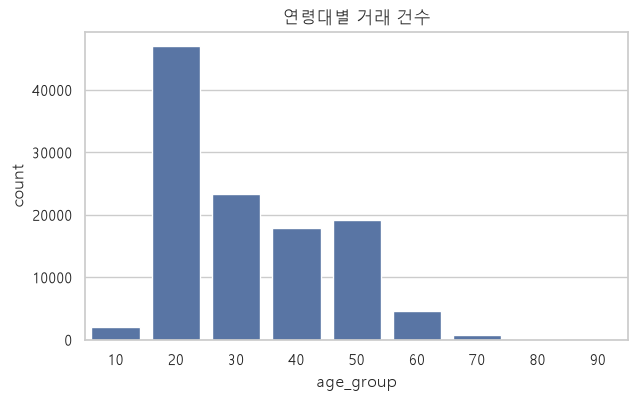

1. 연령대별 거래 건수: 
20대가 46,971건으로 압도적이고, 
30~50대가 1.8만~2.3만으로 비슷한 수준을 유지하다가 60대 이후 급감한다. 
10대(1,956건)도 적다.


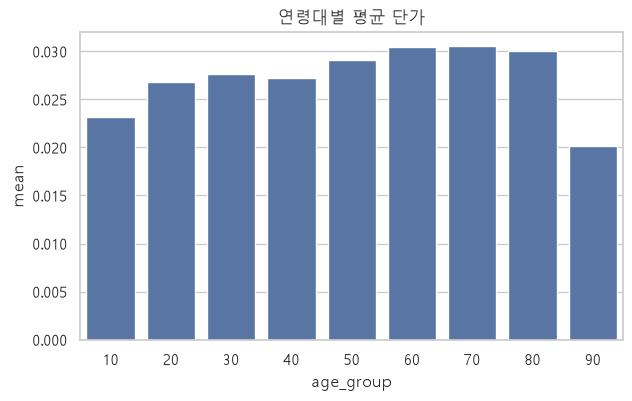

2. 연령대별 평균 단가: 
연령대가 올라갈수록 구매 단가의 평균값은 완만히 상승한다. 
최고값과 최저값이 폭이 크지 않으며, 80,90대(62건, 6건)는 표본이 적다는 것을 알고 값을 봐야 한다.


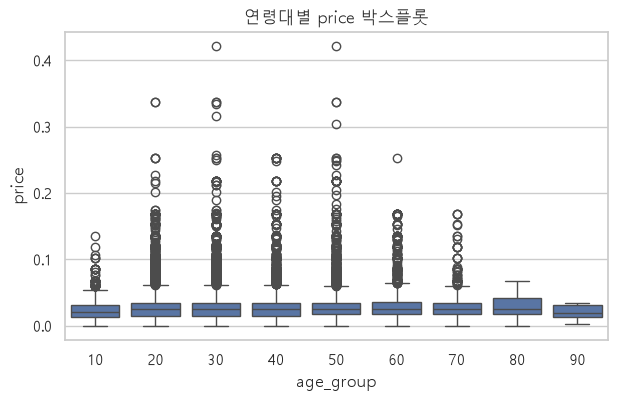

3. 연령대별 단가 박스플롯: 
모든 연령대에서 상자가 바닥에 눌리고 이상치가 위쪽으로 길게 뻗어 있다. 
가격분포가 심하게 치우져 있어 연령대별 평균 차이는 소수의 고가 거래가 끌어올린 결과일 수 있다.


In [6]:
agg = df.groupby('age_group')['price'].agg(['count', 'mean', 'median', 'std'])
display(agg)
display(df['price'].max())
display(df['price'].min())

# 1
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=agg.reset_index(), x='age_group', y='count')
ax.set_title('연령대별 거래 건수')
plt.show()
print('1. 연령대별 거래 건수: \n20대가 46,971건으로 압도적이고, \n30~50대가 1.8만~2.3만으로 비슷한 수준을 유지하다가 60대 이후 급감한다. \n10대(1,956건)도 적다.')

# 2
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=agg.reset_index(), x='age_group', y='mean')
ax.set_title('연령대별 평균 단가')
plt.show()
print('2. 연령대별 평균 단가: \n연령대가 올라갈수록 구매 단가의 평균값은 완만히 상승한다. \n최고값과 최저값이 폭이 크지 않으며, 80,90대(62건, 6건)는 표본이 적다는 것을 알고 값을 봐야 한다.')

# 3
plt.figure(figsize=(7, 4))
ax = sns.boxplot(data=df, x='age_group', y='price')
ax.set_title('연령대별 price 박스플롯')
plt.show()
print('3. 연령대별 단가 박스플롯: \n모든 연령대에서 상자가 바닥에 눌리고 이상치가 위쪽으로 길게 뻗어 있다. \n가격분포가 심하게 치우져 있어 연령대별 평균 차이는 소수의 고가 거래가 끌어올린 결과일 수 있다.')

**종합 인사이트**

연령대(age_group)를 기준으로 거래 건수와 평균 단가를 집계하고, 막대그래프 2개와 박스플롯으로 확인했다.

거래량은 20대에 압도적으로 몰려 있지만(46,971건, 전체의 41%), 평균 단가는 오히려 50~70대가 높다(0.0291~0.0305 vs 20대 0.0268). 즉 "많이 사는 층"과 "비싸게 사는 층"이 서로 다르다.

다만 이 차이를 그대로 믿기는 어렵다. 최고와 최저의 차이가 1.5배에 그치고, 박스플롯을 보면 모든 연령대에서 분포가 크게 겹친다. 가격이 오른쪽으로 심하게 치우쳐 있어(왜도 2.87) 소수의 고가 거래가 평균을 끌어올렸을 가능성도 있다. 연령대별로 선호하는 상품군이 달라서 생긴 차이일 수도 있는데, 이 그림만으로는 구분할 수 없다.

## 3. 선택 EDA 미션 카탈로그
> 🔧 **이 절은 선택입니다.** 원하는 것만 골라서 하세요 — 전부 할 필요 없습니다. 각 미션은 **발제문의 심화 분석 목표**를 문제로 만든 것이고, day07·day08 교안의 도구를 응용하면 대부분 시작할 수 있습니다.

| 난이도 | 선택 미션 | 쓰는 도구 | 예상 시간 |
|---|---|---|---|
| ★ | 1. 산점도 등 다양한 형식으로 시각화 | `scatterplot`·`pairplot` | 15분 |
| ★ | 2. 고객 속성 × 채널 교차분석 | `crosstab`·`heatmap` | 15분 |
| ★★ | 3. 로그 변환·정규화(z-score·Min-Max)로 분포 비교 | `np.log`·표준화 계산 | 20분 |
| ★★ | 4. 이상치 고객·거래 탐색 전략 | IQR 규칙·`boxplot` | 20분 |
| ★★ | 5. 월별·분기별 평균 매출 — 추세와 시즌성 | `dt.quarter`·`lineplot` | 20분 |
| ★★ | 6. 채널 비중 해석 보정 — 비율(%)과 ARPU | `nunique`·비율 계산 | 20분 |
| ★★★ | 7. 고객별 총 구매액 상위 20% vs 하위 20% | `qcut`·`groupby` | 25분 |
| ★★★ | 8. 월별 매출의 3개월 롤링 평균 | `rolling().mean()` | 20분 |

> ⚠️ **이 데이터의 기간은 1년(2019-01-01 ~ 2019-12-31)입니다.** 그래서 5·8번은 **"연도별 추세"가 아니라 "1년 안의 월별 흐름"** 까지만 말할 수 있습니다. 발제문에는 "수년간"이라고 적혀 있지만, 여러분의 데이터로 직접 확인한 사실이 우선입니다.

### 선택 미션 1 (★) — 산점도 등 다양한 형식으로 시각화
> 발제문 심화 분석 목표 ①

**비즈니스 질문**: "많이 사는 고객"과 "비싸게 사는 고객"은 같은 사람인가?

- **무엇을 만드나**: **고객 한 명을 점 하나로** 만든 표(구매건수·총구매액·평균구매액)를 준비해 산점도를 그리고, 세 변수를 한 번에 보는 격자 그림(`pairplot`)까지 그립니다. 거래 한 건이 아니라 **고객 한 명**이 관측 단위가 되는 것이 핵심입니다.
- **이렇게 나오면 맞다**: 산점도에서 구매건수가 늘면 총구매액도 대체로 늘지만(우상향), **평균구매액과 구매건수 사이에는 그런 경향이 거의 안 보입니다** — 이 두 그림의 차이를 한 줄로 설명할 수 있으면 성공입니다.
- **함정**: 고객 대부분이 구매 1~2건이라 점이 왼쪽에 뭉칩니다 — `alpha` 로 투명하게 하거나 표본을 쓰세요. `pairplot` 은 그림 단위 함수라 `figsize` 대신 `height` 를 씁니다(수만 행을 그대로 넣으면 매우 느립니다).

,count,sum,avg
customer_id,,,
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,1,0.025407,0.025407
00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,1,0.015237,0.015237
0000f1c71aafe5963c3d195cf273f7bfd50bbf17761c9199e53dbb81641becd7,1,0.016034,0.016034
0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37e011580a479e80aa94,5,0.142966,0.028593
00023e3dd8618bc63ccad995a5ac62e21177338d642d66b42e0038c6b10f655a,1,0.027136,0.027136


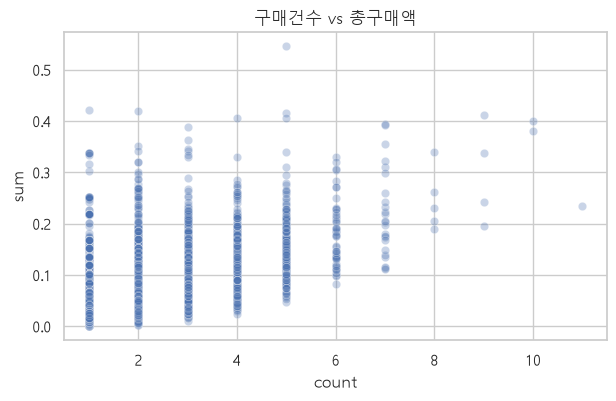

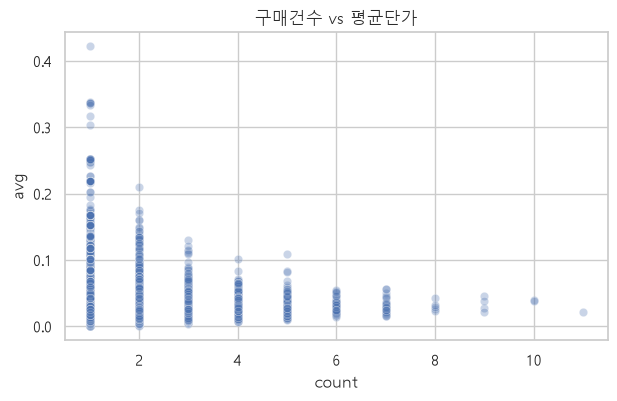

구매건수 vs 총구매액  r = 0.600
구매건수 vs 평균단가  r = 0.018
구매건수와 총구매액은 뚜렷한 양의 관계를 보이지만(r=0.600 - 정비례), 구매건수와 평균단가는 사실상 무관하다(r=0.018 - 관계 없음) 
자주 사는 고객이 더 비싼 상품을 사는 것은 아니다.


In [7]:
# ── 쓸 도구 ─────────────────────────────────────────
#   고객 단위 표: df.groupby('customer_id').agg(…) 로 건수·합계를 구하고, 평균구매액은 두
#     컬럼을 나눠 만듭니다.
#   산점도: sns.scatterplot(data=…, x=…, y=…, alpha=…) — 점이 많으면 <표>.sample(n=…,
#     random_state=42) 로 표본을 씁니다.
#   여러 수치 변수를 한 번에: sns.pairplot(<수치 컬럼만 남긴 표>, height=…) — 대각선은 각
#     변수의 분포, 나머지 칸은 두 변수의 산점도입니다.
#   관계의 세기를 숫자로도 보고 싶으면 상관 도구.

customer = df.groupby('customer_id')['price'].agg(['count', 'sum'])
customer['avg'] = customer['sum'] / customer['count']
display(customer.head())

fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=customer, x='count', y='sum', alpha=0.3, ax=ax)
ax.set_title('구매건수 vs 총구매액')
plt.show()

plt.figure(figsize=(7, 4))
ax2 = sns.scatterplot(data=customer, x='count', y='avg', alpha=0.3)
ax2.set_title('구매건수 vs 평균단가')
plt.show()

print(f"구매건수 vs 총구매액  r = {customer['count'].corr(customer['sum']):.3f}")
print(f"구매건수 vs 평균단가  r = {customer['count'].corr(customer['avg']):.3f}")
print('구매건수와 총구매액은 뚜렷한 양의 관계를 보이지만(r=0.600 - 정비례), 구매건수와 평균단가는 사실상 무관하다(r=0.018 - 관계 없음) \n자주 사는 고객이 더 비싼 상품을 사는 것은 아니다.')

# sns.pairplot(customer.sample(n=3000, random_state=42),height=2)

In [8]:
print('구매 1건 고객:', (customer['count'] == 1).sum(), '명')
print('전체 고객:', len(customer), '명')
print('비율: %.1f%%' % (100 * (customer['count'] == 1).mean()))

구매 1건 고객: 78195 명
전체 고객: 93976 명
비율: 83.2%


전체 고객 93,976명 중 83%가 1년에 단 1건만 구매했다. 구매 빈도와 평균 단가는 사실상 무관하다고 볼 수 있다.

### 선택 미션 2 (★) — 고객 속성 × 채널 교차분석
> 발제문 심화 분석 목표 ⑦

**비즈니스 질문**: 멤버십 상태나 뉴스 구독 습관에 따라 **주로 쓰는 채널**이 다른가?

- **무엇을 만드나**: 고객 속성(`club_member_status`·`fashion_news_frequency`·`age_group` 중 둘 이상)과 채널의 교차표를 만들고, **행 기준 비율**로 바꿔 히트맵으로 보여줍니다. 비율표와 함께 **건수표도** 제시해 표본이 작은 범주를 드러냅니다.
- **이렇게 나오면 맞다**: 비율표와 건수표를 나란히 놓았을 때, **비중이 극단적으로 보이는 범주가 실은 건수가 아주 적다**는 것을 스스로 지적할 수 있으면 성공입니다. 어떤 속성에서는 범주 간 비중 차이가 거의 없을 수도 있는데, 그 "차이가 없다"도 결론입니다.
- **함정**: 비율만 보면 **50건짜리 범주와 10만 건짜리 범주가 똑같은 크기의 칸**으로 보입니다 — 건수를 함께 보지 않으면 "탈퇴 고객은 96%가 온라인" 같은 문장을 근거 없이 쓰게 됩니다. `fmt='d'` 는 비율표에서 에러가 납니다(`'.2f'` 로).

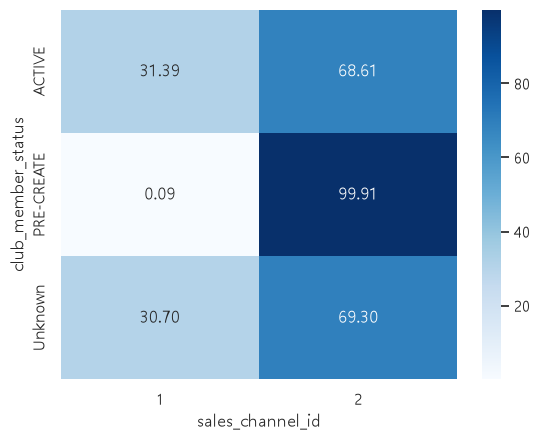

sales_channel_id,1,2
club_member_status,,
ACTIVE,34127,74604
PRE-CREATE,2,2213
Unknown,917,2070


PRE-CREATE 고객은 구매의 99.9%가 온라인에서 발생해(2,215건 중 오프라인 2건)
 다른 멤버십 그룹(68~69%)과 뚜렷이 구분된다. 반면 ACTIVE와 Unknown은 채널 비중이 
거의 같아 구분되지 않는다. 따라서 가입 전환 캠페인은 온라인 접점에 집중하는 것이 
타당하다(PRE-CREATE의 경우 가입 대기라서 온라인만 쓰는건지, 온라인만 써서 가입 대기로
 남아있는지 인과관계를 알 수 없다.


In [9]:
# ── 쓸 도구 ─────────────────────────────────────────
#   교차표: pd.crosstab(<속성 시리즈>, <채널 시리즈>) — 비율은 normalize='index'.
#   히트맵: sns.heatmap(<비율표>, annot=True, fmt='.2f', cmap='Blues').
#   표본 크기 확인: 비율표와 나란히 normalize 없는 건수표를 함께 출력합니다.

d = df[df['sales_channel_id'] != 0]        # 4-5 결정대로 채널 분석에선 0 제외
ratio = pd.crosstab(d['club_member_status'], d['sales_channel_id'], normalize='index')*100
cnt = pd.crosstab(d['club_member_status'], d['sales_channel_id'])
sns.heatmap(ratio, annot=True, fmt='.2f', cmap='Blues')
plt.show()
display(cnt)
print('PRE-CREATE 고객은 구매의 99.9%가 온라인에서 발생해(2,215건 중 오프라인 2건)\n ' \
'다른 멤버십 그룹(68~69%)과 뚜렷이 구분된다. 반면 ACTIVE와 Unknown은 채널 비중이 \n' \
'거의 같아 구분되지 않는다. 따라서 가입 전환 캠페인은 온라인 접점에 집중하는 것이 \n' \
'타당하다(PRE-CREATE의 경우 가입 대기라서 온라인만 쓰는건지, 온라인만 써서 가입 대기로\n' \
' 남아있는지 인과관계를 알 수 없다.')

### 선택 미션 3 (★★) — 로그 변환·정규화(z-score·Min-Max)로 분포 비교
> 발제문 심화 분석 목표 ④

**비즈니스 질문**: 치우친 가격 분포를 **어떻게 손봐야** 고객·상품군끼리 공정하게 비교할 수 있나?

- **무엇을 만드나**: price 에 ① 로그 변환 ② z-score 표준화 ③ Min-Max 정규화를 각각 적용해, **네 가지 버전(원본 포함)의 왜도와 히스토그램**을 비교합니다. 그다음 z-score 를 써서 **상품 대분류별 평균 z** 를 구해 어느 군이 전체 평균보다 비싼지 봅니다.
- **이렇게 나오면 맞다**: **로그 변환만 왜도가 크게 줄고, z-score·Min-Max 는 왜도가 원본과 똑같이 남습니다.** 왜 그런지 한 줄로 설명할 수 있으면 이 미션의 핵심을 얻은 것입니다.
- **함정**: z-score·Min-Max 는 축의 **위치와 크기만 바꾸는 선형 변환**이라 분포 **모양**(치우침)은 그대로입니다 — "정규화하면 정규분포가 된다"는 오해를 여기서 깨야 합니다. `np.log` 는 0 이하에서 무한대·NaN 이 됩니다.

In [10]:
# ── 쓸 도구 ─────────────────────────────────────────
#   로그 변환: np.log(<값>).
#   z-score: 평균을 빼고 표준편차로 나눕니다(.mean()·.std(ddof=1)).
#   Min-Max: 최솟값을 빼고 (최대−최소)로 나눕니다.
#   왜도는 stats.skew(<값>), 그림은 subplots + histplot.
#   군별 비교: 새로 만든 z 값을 컬럼으로 붙여(df.assign(<이름>=…)) groupby(<군>) 으로 평균.

# 여기에 코드를 작성하세요

### 선택 미션 4 (★★) — 이상치 고객·거래 탐색 전략
> 발제문 심화 분석 목표 ⑥

**비즈니스 질문**: "비정상적으로 큰" 거래와 고객을 어떻게 찾고, 찾은 다음 **제거할지 남길지** 어떻게 정하나?

- **무엇을 만드나**: IQR 1.5배 규칙으로 ① **거래 단위** 이상치와 ② **고객 총구매액 단위** 이상치를 각각 찾아, 건수·비율·**그들이 차지하는 매출 비중**을 출력합니다. 그리고 그 이상치를 **제거할지·남길지·따로 표시(플래그)할지**를 근거와 함께 한 줄로 적습니다.
- **이렇게 나오면 맞다**: 이상치 거래는 전체의 **5% 안팎인데 매출은 그보다 훨씬 큰 몫**을 차지합니다 — 그래서 "이상치니까 지운다"가 위험하다는 결론이 데이터에서 나옵니다. 거래 단위와 고객 단위의 결과가 다르다는 것도 확인하세요.
- **함정**: **이상치 = 오류가 아닙니다.** 여기서 잡힌 것은 대부분 정상적인 고가 상품(코트·신발)입니다 — 지우면 매출의 상당 부분이 사라집니다. 그리고 IQR 규칙은 **한쪽으로 치우친 분포에서 상단을 과하게 잡는다**는 한계가 있으니, 로그 변환 후 다시 보거나 상위 1% 같은 다른 기준과 비교해 보세요.

In [11]:
# ── 쓸 도구 ─────────────────────────────────────────
#   IQR 규칙: .quantile([0.25, 0.75]) 로 Q1·Q3 -> IQR -> 상한은 Q3 + 1.5 × IQR.
#   이상치만 고르기: 불리언 조건으로 필터 — 비율은 조건의 .mean(), 건수는 .sum().
#   고객 단위: df.groupby('customer_id')['price'].sum() 에 같은 규칙을 적용합니다.
#   매출 비중: 이상치의 합 ÷ 전체 합.
#   그림: sns.boxplot(x=<시리즈>) — 상자 밖 점이 이 규칙이 말하는 이상치입니다.
#   어떤 상품군에서 나오는지 보려면 value_counts().head().

# 여기에 코드를 작성하세요

### 선택 미션 5 (★★) — 월별·분기별 평균 매출 — 추세와 시즌성
> 발제문 심화 분석 목표 ⑤

**비즈니스 질문**: 매출이 특정 시기에 몰리는가? 그 급증을 "성장"이라고 불러도 되는가?

- **무엇을 만드나**: 월별·분기별로 **총매출·건수·평균가**를 집계해 표로 만들고, 월별 흐름을 꺾은선으로, 분기별 비교를 막대로 그립니다. 그리고 **급증한 달이 건수 때문인지 단가 때문인지** 구분해 한 줄로 적습니다.
- **이렇게 나오면 맞다**: 총매출이 가장 큰 달과 평균가가 가장 큰 달이 **서로 다릅니다** — 그래서 "매출이 늘었다"를 **건수 증가**와 **단가 상승**으로 쪼개 설명할 수 있으면 성공입니다.
- **함정**: 이 데이터는 **1년뿐**이라 "증가 추세/감소 추세" 같은 장기 판단을 할 수 없습니다(작년 같은 달과 비교할 수 없으므로). 시즌 이벤트(블랙프라이데이·연말연시)로 인한 급증을 성장으로 단정하지 말라는 발제문 경고가 바로 이 지점입니다.

,sum,count,mean
month,,,
1,231.007881,8788,0.026287
2,219.217373,8110,0.027031
3,252.455016,8883,0.028420
4,293.735135,10308,0.028496
5,304.514796,10910,0.027912
6,341.847016,13465,0.025388
7,278.683644,12635,0.022056
8,218.816796,8881,0.024639
9,275.448407,8515,0.032349


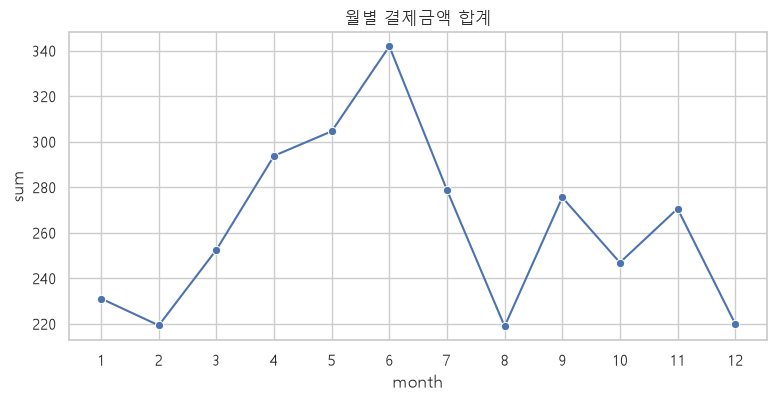

6월에 341.8로 정점을 찍고, 2월(219.2)·8월(218.8)·12월(219.9)이 저점이다. 
특정 달에 매출이 몰리는 시즌성이 보인다.


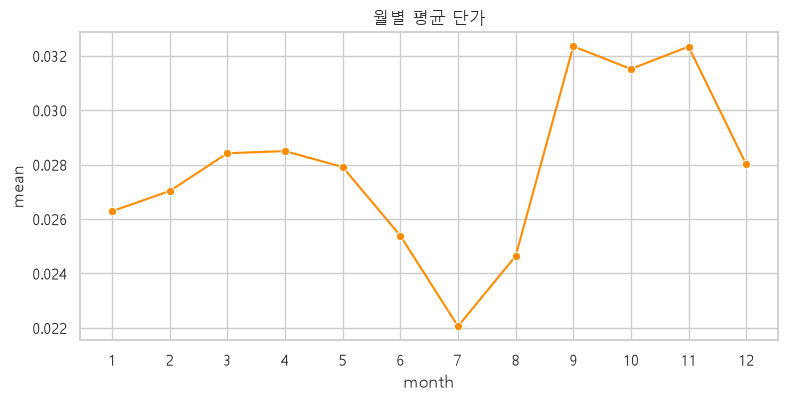

총매출과 봉우리 위치가 다르다. 7월이 0.0221로 가장 낮고 9·11월이 0.0323으로 가장 높아, 
매출이 큰 달과 비싼 상품이 팔린 달이 일치하지 않는다.


,sum,count,mean
quarter,,,
1,702.680270,25781,0.027256
2,940.096947,34683,0.027105
3,772.948846,30031,0.025738
4,737.238440,24049,0.030656


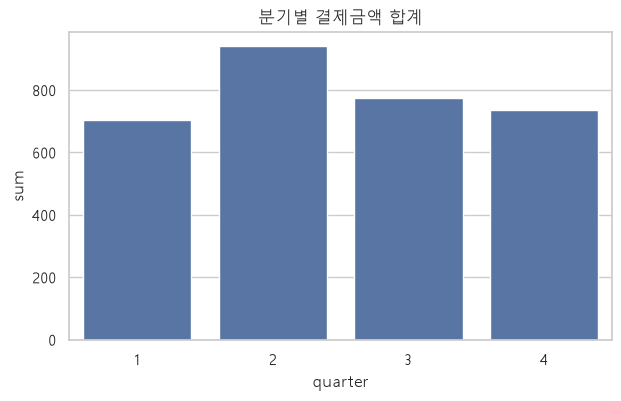

2분기가 940.1로 전체 매출의 29.8%를 차지해 가장 크며, 이는 건수(34,683건)가 가장 많았기 때문이다. 
반면 4분기는 건수가 가장 적은데도(24,049건) 평균 단가가 0.0307로 높아 매출 비중 23.4%를 유지했다.


In [12]:
# ── 쓸 도구 ─────────────────────────────────────────
#   분기 파생: 날짜형 컬럼의 .dt.quarter (1~4).
#   집계: groupby(<월 또는 분기>).agg(…) 로 합계·건수·평균을 한 표에.
#   그림: lineplot(추이) + barplot(분기 비교). 집계 결과는 reset_index() 후 넣습니다.
#   최대·최소 달 찾기: .idxmax()·.idxmin().

# 월별 집계
monthly = df.groupby('month')['price'].agg(['sum', 'count', 'mean'])
display(monthly)

# 그림 1 — 월별 합계
plt.figure(figsize=(9, 4))
ax = sns.lineplot(data=monthly.reset_index(), x='month', y='sum', marker='o')
ax.set_xticks(range(1, 13))
ax.set_title('월별 결제금액 합계')
plt.show()
print('6월에 341.8로 정점을 찍고, 2월(219.2)·8월(218.8)·12월(219.9)이 저점이다. \n특정 달에 매출이 몰리는 시즌성이 보인다.')

# 그림 2 — 월별 평균 단가
plt.figure(figsize=(9, 4))
ax = sns.lineplot(data=monthly.reset_index(), x='month', y='mean', marker='o', color='darkorange')
ax.set_xticks(range(1, 13))
ax.set_title('월별 평균 단가')
plt.show()
print('총매출과 봉우리 위치가 다르다. 7월이 0.0221로 가장 낮고 9·11월이 0.0323으로 가장 높아, \n매출이 큰 달과 비싼 상품이 팔린 달이 일치하지 않는다.')

# 분기별 집계
df['quarter'] = df['t_dat'].dt.quarter
quarterly = df.groupby('quarter')['price'].agg(['sum', 'count', 'mean'])
display(quarterly)

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=quarterly.reset_index(), x='quarter', y='sum')
ax.set_title('분기별 결제금액 합계')
plt.show()
print('2분기가 940.1로 전체 매출의 29.8%를 차지해 가장 크며, 이는 건수(34,683건)가 가장 많았기 때문이다. \n반면 4분기는 건수가 가장 적은데도(24,049건) 평균 단가가 0.0307로 높아 매출 비중 23.4%를 유지했다.')

6월과 9·11월은 매출이 오르는 방식이 다르다.

6월은 총매출 341.8로 연중 최고지만 평균 단가는 0.0254로 낮은 편이다. 거래 건수가 13,465건으로 연중 최다였기 때문에, 이 달의 매출은 단가가 아니라 건수가 만든 것이다.

반면 9월(0.0323)과 11월(0.0323)은 평균 단가가 가장 높다. 건수는 8,515건·8,365건으로 6월의 3분의 2 수준인데도 총매출이 275.4·270.5를 기록했다. 적게 팔고도 비싸게 팔아 매출을 방어한 달이다.

두 패턴은 마케팅 액션이 다르다. 6월형은 방문·구매 빈도를 끌어올리는 시기이고, 9·11월형은 고가 상품 노출을 강화할 시기다.

**한계점**: 다만 2019년 1년치뿐이라 이 패턴이 매년 반복되는 계절성인지, 그해에만 있었던 일인지는 이 데이터로 확인할 수 없다.

### 선택 미션 6 (★★) — 채널 비중 해석 보정 — 비율(%)과 ARPU
> 발제문 심화 분석 목표 FAQ(표본 크기 차이 보정)

**비즈니스 질문**: 온라인이 오프라인보다 매출이 크다는 말은, 온라인 **기록이 더 많아서** 생긴 착시가 아닐까?

- **무엇을 만드나**: 채널별로 **건수·총매출·고객 수**를 구하고, 여기서 ① 건수 비중(%) ② 매출 비중(%) ③ **ARPU(고객당 평균 구매액)** ④ 고객당 구매 건수 ⑤ 거래당 평균가를 계산한 표를 만듭니다. 그리고 **표본 크기 차이를 보정한 뒤에도 결론이 유지되는지** 한 줄로 적습니다.
- **이렇게 나오면 맞다**: 채널별 ARPU 와 거래당 평균가를 나란히 놓았을 때, **"온라인 우세"가 단순히 기록 수 차이 때문이 아니라는 것(또는 그 반대)** 을 근거를 들어 말할 수 있으면 성공입니다.
- **함정**: **채널별 고객 수를 더하면 전체 고객 수보다 많습니다** — 두 채널을 모두 쓴 고객이 양쪽에 세어지기 때문입니다(그래서 ARPU 는 채널별로만 비교하고 합산하지 마세요). 그리고 이 데이터는 애초에 온라인 기록이 더 많이 수집된 표본이라, 보정 후에도 **"시장 전체에서 온라인이 우세하다"로 일반화할 수는 없습니다.**

In [13]:
# ── 쓸 도구 ─────────────────────────────────────────
#   고객 수는 중복을 뺀 개수 — agg(<이름>=('customer_id', 'nunique')).
#   비중: 각 값을 <컬럼>.sum() 으로 나눕니다.
#   ARPU = 총매출 ÷ 고객 수, 고객당 건수 = 건수 ÷ 고객 수, 거래당 평균가 = 총매출 ÷ 건수.
#   두 채널을 모두 쓴 고객 수: df.groupby('customer_id')['sales_channel_id'].nunique() 가 2
#     인 고객을 셉니다.

# 여기에 코드를 작성하세요

### 선택 미션 7 (★★★) — 고객별 총 구매액 상위 20% vs 하위 20%
> 발제문 심화 분석 목표 ②

**비즈니스 질문**: 우리 매출은 소수의 고객에게 얼마나 몰려 있고, 그 고객들은 무엇이 다른가?

- **무엇을 만드나**: 고객별 **총구매액·구매건수·평균구매액·온라인 비중**을 만든 뒤 총구매액으로 **5분위**로 나눠, **상위 20%와 하위 20%** 의 지표를 비교하는 표와 그림을 만듭니다. 두 그룹이 **전체 매출에서 차지하는 비중**도 함께 계산합니다.
- **이렇게 나오면 맞다**: 상위 20% 가 전체 매출의 **40% 이상**을 차지하고, 하위 20% 는 10% 미만입니다. 그리고 상위 그룹은 평균구매액·구매건수·온라인 비중이 **모두** 더 높게 나옵니다 — 세 지표 중 어느 것이 가장 크게 벌어지는지 말할 수 있으면 성공입니다.
- **함정**: `qcut` 은 **같은 개수**로 나누므로, 총구매액이 같은 고객이 많으면 경계가 딱 20%가 아닐 수 있습니다. 그리고 이 5분위는 **총구매액으로 만든 것**이라 "상위 20%가 총구매액이 크다"는 것은 동어반복입니다 — 의미 있는 발견은 **평균구매액·건수·채널처럼 나누는 데 쓰지 않은 지표**에서 나옵니다.

In [14]:
# ── 쓸 도구 ─────────────────────────────────────────
#   고객 단위 표: df.groupby('customer_id').agg(…) — 온라인 비중은 "채널이 2인가"라는
#     참/거짓 컬럼의 평균으로 구할 수 있습니다(df.assign(<이름>=<조건>) 으로 먼저 컬럼을
#     만들면 편합니다).
#   5분위 나누기: pd.qcut(<시리즈>, q=5, labels=[…]) — 같은 개수로 나눕니다(pd.cut 은 같은
#     폭으로 나눔).
#   그룹 비교: groupby(<그룹 컬럼>, observed=True)[<지표들>].mean().
#   매출 점유율: 그룹별 합계 ÷ 전체 합계.
#   그림: barplot 으로 그룹별 지표 비교.

# 여기에 코드를 작성하세요

### 선택 미션 8 (★★★) — 월별 매출의 3개월 롤링 평균
> 발제문 심화 분석 목표 ③

**비즈니스 질문**: 월별 매출이 들쭉날쭉할 때, **노이즈를 걷어낸 흐름**은 어떤 모양인가?

- **무엇을 만드나**: 월별 총매출 표를 만들고 **3개월 롤링 평균** 컬럼을 추가해, 원래 선과 롤링 선을 **한 그림에 겹쳐** 그립니다. 앞의 두 달이 왜 비어 있는지, 롤링 창을 6개월로 늘리면 무엇이 달라지는지도 한 줄로 적습니다.
- **이렇게 나오면 맞다**: 롤링 선이 원래 선보다 **매끄럽고**, 1·2월 자리는 값이 없어 선이 3월부터 시작합니다. 두 선이 어긋나는 달을 짚어 "그 달만 튀었다"고 말할 수 있으면 성공입니다.
- **함정**: 롤링 평균은 **창 크기−1 개월만큼 뒤로 늦게 반응**합니다(그래서 앞부분이 NaN). 우리 데이터는 12개월뿐이라 6개월 창을 쓰면 점이 7개만 남아 추세라고 부르기 어렵습니다 — **3개월 창이 이 데이터에 맞는 선택**입니다. 그리고 월별 합계는 **그 달의 일수·표본 수**에 영향을 받으니, 필요하면 평균가와 함께 보세요.

In [15]:
# ── 쓸 도구 ─────────────────────────────────────────
#   월별 집계: df.groupby('month')['price'].sum() — 그래프에 넣으려면
#     reset_index(name=<이름>).
#   롤링 평균: <시리즈>.rolling(<창 크기>).mean() — 창 크기 3 이면 3개월 이동 평균.
#   겹쳐 그리기: plt.plot(<x>, <y>, label=…) 을 두 번 부르고 plt.legend().
#   월 눈금 고정: plt.xticks(range(1, 13)).

# 여기에 코드를 작성하세요

## 4. 관찰 정리 (서술)
**이 절에서 할 일**: 위에서 본 집계·그래프를 근거로 **한 문단짜리 인사이트**를 씁니다. "A 이다" 로 끝내지 말고, **다른 설명 가능성**(다른 변수가 진짜 원인일 수도 있다는 점)도 함께 짚으세요 — 관찰연구는 상관이지 인과가 아닙니다.

**쓰는 순서**: ① 어떤 집계·그래프를 봤나 → ② 거기서 무엇을 관찰했나 → ③ 다른 설명 가능성은 없는가 → ④ 우연인지 검정으로 확인하고 싶은 질문.

- 어떤 축(연령대·채널·상품군 등)에서 가장 뚜렷한 차이를 봤나요?
- 그 차이가 우연이 아니라고 자신 있게 말할 수 있나요, 아니면 검정으로 확인하고 싶은가요?
- 표본 크기가 작은 범주나, 온라인에 치우친 이 데이터의 한계를 함께 적었나요?

> ✅ **여기까지 되면 통과**: 한 문단 서술에 관찰 + 다른 설명 가능성 + 다음 파트로 넘길 질문이 모두 있으면 됩니다.

연령대(age_group), 멤버십(club_member_status), 월(month)을 기준으로 결제금액을 집계하고, 바플롯, 박스플롯, 산점도, 히트맵, 꺾은선으로 연령대별, 멤버십별, 월별(분기별) 집계를 확인했다. 고객 단위 표(customer_id 기준 구매건수, 총구매액, 평균단가) 그래프도 만들었다.

첫째, 거래량은 20대에 몰려있지만 평균 단가는 약소하지만 50~70대가 더 높다. 그리고 실제 구매액이 아닌 상대적인 구매액 환산 비율이기 때문에 이 점을 참고해서 봐야 한다. 결론은 많이 사는 층과 비싸게 사는 층이 다르다는 것이다.
둘째, 고객 93,976명 중 83%가 1년에 단 1건만 구매했고, 구매 빈도와 평균 단가는 사실상 무관하다.
셋째, PRE-CREATE(가입대기)고객은 구매의 99.9%가 channel 2(온라인)에서 발생해 다른 멤버십 그룹과 뚜렷하게 구분된다.
마지막으로, 월별로는 6월이 최다 건수로 총매출 1위였고, 9월과 11월은 건수가 적은데도 평균 단가가 가장 높았다.

연령대별 단가 차이는 나이 자체가 아니라 연령대별로 선호하는 상품군이 다르기 때문일 수도 있다. 이 데이터로는 두 가지를 구분할 수 없다. 온라인 비중이 높게 나온 사실도 온라인 기록이 더 많이 수집된 표본 편향일 가능성이 있다. 월별 패턴도 역시 2019년 1년치뿐이기 때문에 매년 반복되는 계절성인지, 2019년도만의 현상인지 확인할 수 없다. 또한 80대,90대처럼 표본이 매우 적으면 값이 불안정하므로 해석에서 제외하거나 특별히 신경써야 한다.

### [03으로 넘길 질문]
- 연령대별 평균 단가 차이가 통계적으로 유의한가? 유의하다면 효과크기는 실질적으로 의미 있는 수준인가?
- 채널별(온라인·오프라인) 평균 단가 차이는 우연으로 볼 수 있는가?